In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
pops_exp = pd.read_csv('../../../../../../../../s/project/gene_embedding/funcrvp_embeddings/pops_mat_exp_d256.tsv', sep='\t')
pops_exp


,gene_id,0,1,2,3,4,5,6,7,8,...,246,247,248,249,250,251,252,253,254,255
0,ENSG00000186092,31.985289,25.948684,-15.762883,5.101555,-25.972287,-20.366169,5.950797,-11.341337,4.528122,...,-0.418659,-0.910724,1.303047,-0.455800,0.370493,-0.734093,-0.080420,1.598871,0.786777,-0.166567
1,ENSG00000235249,28.898286,25.075698,-16.322043,5.892574,-26.686822,-22.191523,5.167148,-11.056583,4.160436,...,-0.102790,-0.755268,0.761916,0.125767,1.554828,-0.585317,-0.423992,1.038627,0.615826,0.518443
2,ENSG00000185097,28.991321,24.841130,-16.292335,6.096482,-26.607834,-22.200097,5.196613,-10.912608,4.331590,...,0.161043,-0.948743,0.700445,0.263497,1.740225,-0.643595,-0.547888,0.938271,0.648890,0.416320
3,ENSG00000187634,34.294784,0.046676,-3.275223,-9.341926,15.269522,0.029242,-9.751682,-10.183288,-2.149011,...,2.415804,-2.930334,-0.757868,-1.053608,-1.651666,6.999601,-1.437542,2.815025,-1.410621,-1.877809
4,ENSG00000188976,-60.097234,16.922671,-10.659742,25.165829,12.231485,3.971346,-0.462168,0.406390,-5.917177,...,-3.517019,-1.436626,2.162491,-0.207731,3.743680,3.491724,-0.123818,-1.219171,-2.819497,0.258075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18378,ENSG00000165724,-18.984987,16.163869,-18.083578,14.254382,19.379048,-10.638009,5.180862,3.174189,-16.699104,...,2.983626,-0.024898,-3.236726,1.583846,1.747305,-0.935346,-1.962631,-2.676415,-2.464843,-4.003684
18379,ENSG00000197070,-26.927828,29.358507,50.465876,4.027178,-4.570857,16.226492,17.898988,33.141269,8.709330,...,0.646602,-6.065191,2.550688,0.528839,2.719693,-1.371485,-1.557061,0.176313,-3.917971,-0.869687
18380,ENSG00000203993,10.507637,20.473441,-19.652351,5.780455,-20.069006,-16.796220,5.327740,-9.835205,6.997477,...,0.299638,0.997087,-3.118589,1.033580,1.010002,0.021297,-3.283310,-1.418155,0.185014,-1.572184
18381,ENSG00000181090,-51.092136,-32.473979,-1.816036,51.811839,-0.709510,-12.754113,-5.356105,-2.772177,-11.901646,...,-2.912826,-1.680733,0.444432,0.940341,-0.147332,0.995749,-1.522490,-0.774400,-1.399136,0.046701


In [3]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [4]:
NCG_Known_Genes = emogi_predictions[['ID', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pops_exp.merge(NCG_Known_Genes, left_on="gene_id" ,right_on='ID', how='inner').drop(columns=['ID'])
merged.set_index('gene_id', inplace=True)
merged

,0,1,2,3,4,5,6,7,8,9,...,250,251,252,253,254,255,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000187634,34.294784,0.046676,-3.275223,-9.341926,15.269522,0.029242,-9.751682,-10.183288,-2.149011,10.547241,...,-1.651666,6.999601,-1.437542,2.815025,-1.410621,-1.877809,False,False,False,False
ENSG00000188976,-60.097234,16.922671,-10.659742,25.165829,12.231485,3.971346,-0.462168,0.406390,-5.917177,4.359404,...,3.743680,3.491724,-0.123818,-1.219171,-2.819497,0.258075,False,False,False,False
ENSG00000187961,10.432994,-1.960063,-9.470503,11.151478,-7.230180,-4.111201,4.515837,-5.565623,3.871765,1.260847,...,-2.521858,-2.554891,-1.593129,-0.403747,-3.159311,1.765717,False,False,False,False
ENSG00000188290,6.504217,-5.246245,8.260288,-22.455656,-11.562822,-17.877466,2.678445,4.848631,-12.518640,-25.719201,...,-5.903878,-5.355036,-2.951921,-2.112366,-21.585849,14.117028,False,False,False,False
ENSG00000187608,-12.601594,20.358100,84.493775,-44.004509,-19.620230,-14.409736,-35.012072,27.618935,54.184595,-17.008619,...,-5.342909,-4.947811,-12.733427,0.070435,-1.195317,11.087346,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000165802,-0.229336,-24.343599,-0.791341,2.408546,-14.785039,10.519520,6.297625,-10.319861,4.081825,-11.695370,...,-3.410259,-1.555760,-2.347154,0.976417,0.894599,-5.483142,False,False,False,False
ENSG00000182154,-86.946746,33.349758,-17.188702,-39.129237,3.797122,30.361443,24.636569,0.598537,15.949105,-3.698865,...,-6.646235,-0.990403,-0.861345,4.733938,-5.345825,-3.463127,False,False,False,False
ENSG00000165724,-18.984987,16.163869,-18.083578,14.254382,19.379048,-10.638009,5.180862,3.174189,-16.699104,3.797008,...,1.747305,-0.935346,-1.962631,-2.676415,-2.464843,-4.003684,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [5]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    11753
True       593
Name: count, dtype: int64

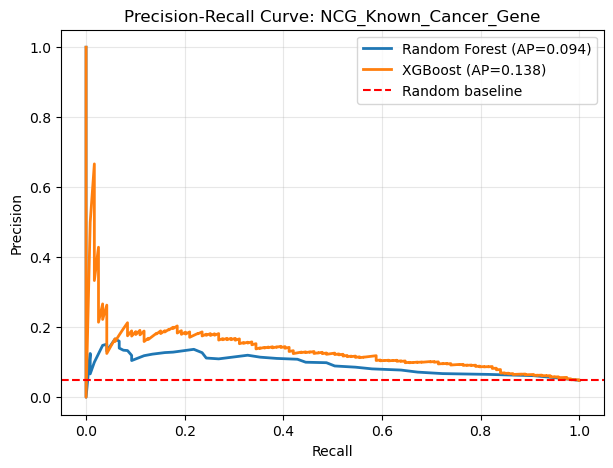

Random Forest - auPRC: 0.094
XGBoost - auPRC: 0.138



In [6]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'Bailey_et_al_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [7]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    11193
True      1153
Name: count, dtype: int64

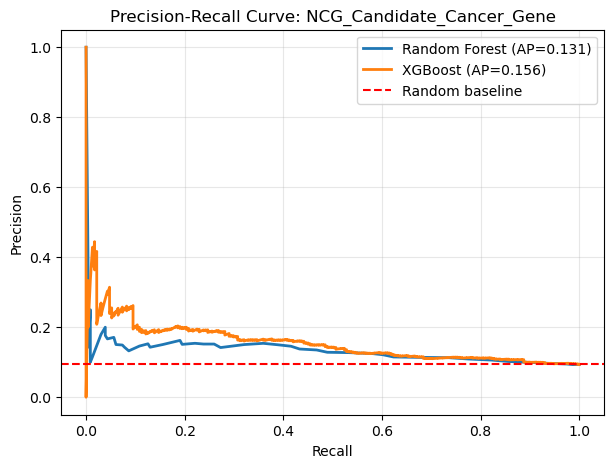

Random Forest - auPRC: 0.131
XGBoost - auPRC: 0.156



In [8]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [9]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    11873
True       473
Name: count, dtype: int64

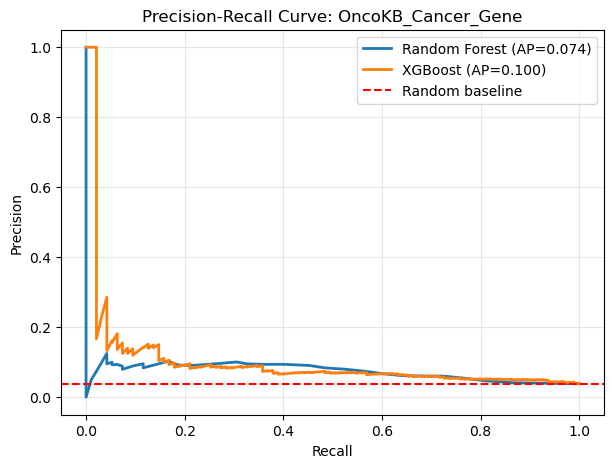

Random Forest - auPRC: 0.074
XGBoost - auPRC: 0.100



In [10]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [11]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    12103
True       243
Name: count, dtype: int64

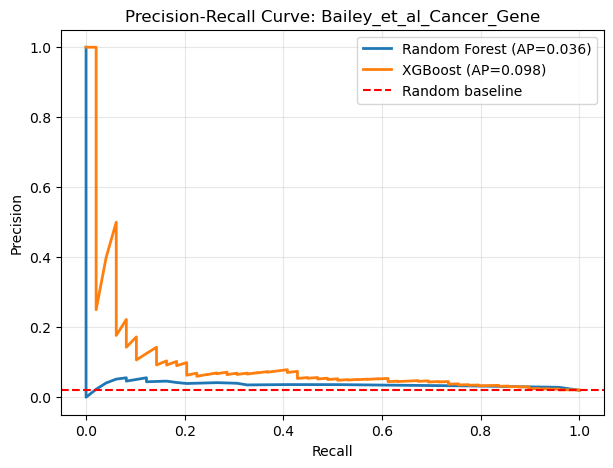

Random Forest - auPRC: 0.036
XGBoost - auPRC: 0.098



In [12]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'Bailey_et_al_Cancer_Gene')